In [19]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import csv
import json
import geopandas as gpd
import numpy as np
import math
import matplotlib.cm as cm
import matplotlib.colors as mcolors


# with open(f"farm_locations.json", "r") as f:
#     loc0 = json.load(f)
# loc=dict((int(key), value) for (key, value) in loc0.items())

# open the json file and create a graph
with open(f"Graph_json/Graph_mean.json", "r") as f:
    data = json.load(f)
G = nx.node_link_graph(data)


### Degree centrality ###

In [4]:
# in degree with a probability minimum
def in_degree_prob_min(G, prob):
    G1 = G.copy()
    # removing edges with a probability lower than the min
    for e in list(G.edges()):
        if G1.edges[e[0], e[1]]['prob'] < prob :
            G1.remove_edge(e[0], e[1])
            
    if len(G1) <= 1:
        return {n: 1 for n in G}

    s = 1.0 / (len(G1) - 1.0)
    centrality = {n: d * s for n, d in G1.in_degree()}
    return centrality

# out degree with a probability minimum
def out_degree_prob_min(G, prob):
    G1 = G.copy()
    # removing edges with a probability lower than the min
    for e in list(G.edges()):
        if G1.edges[e[0], e[1]]['prob'] < prob :
            G1.remove_edge(e[0], e[1])
            
    if len(G1) <= 1:
        return {n: 1 for n in G}

    s = 1.0 / (len(G1) - 1.0)
    centrality = {n: d * s for n, d in G1.out_degree()}
    return centrality

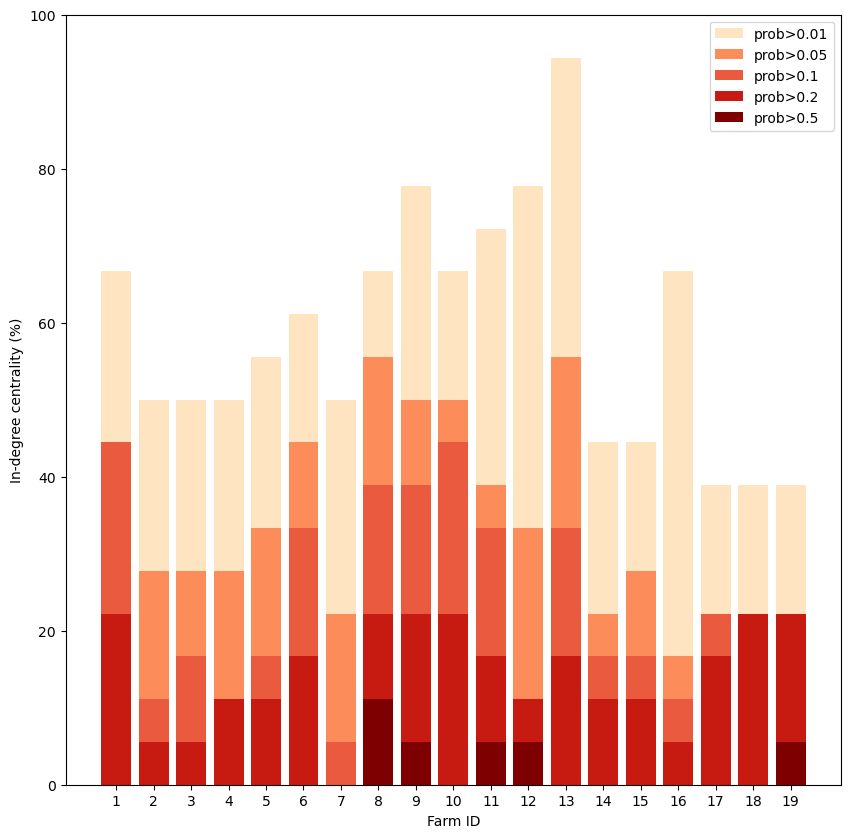

In [39]:
with open(f"Graph_json/Graph_mean.json", "r") as f:
    data = json.load(f)
G = nx.node_link_graph(data)

G1 = G.copy()
for nd in list(G1.nodes()):
    if (nd, nd) in list(G1.edges()):       
        G1.remove_edge(nd, nd)

fig, ax = plt.subplots(figsize=(10, 10))
list_prob = [0.01, 0.05, 0.1, 0.2, 0.5]
farms = np.arange(1, 20)

cmap = plt.get_cmap('OrRd') 
norm = mcolors.LogNorm(vmin=0.005, vmax=max(list_prob))

for prob in list_prob :    
    in_degree_min = in_degree_prob_min(G1, prob)
    degree = []
    for ID in farms :
        degree.append(in_degree_min[ID]*100)
    plt.xticks(farms, farms)
    plt.bar(farms, degree, label = f'prob>{prob}', color=cmap(norm(prob)))
    ax.set_ylim([0, 100])


ax.legend()
#ax.set_title(f'In-degree centrality of each farm according to a minimal probability ({year})')
ax.set_title(f'In-degree centrality of each farm according to a minimal probability (mean)')
ax.set_xlabel("Farm ID")
ax.set_ylabel("In-degree centrality (%)")
plt.show()
#fig.savefig(f'In_degree_centrality_min_prob_{year}')
fig.savefig(f'connectivity_metrics/In_degree_centrality_min_prob_mean')

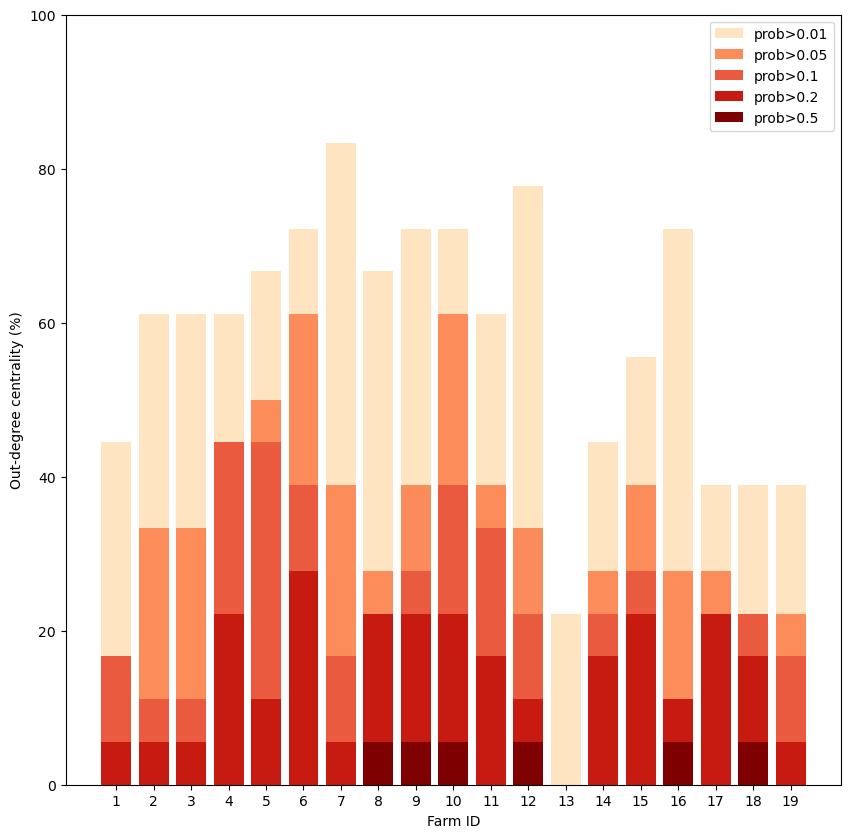

In [43]:
fig, ax = plt.subplots(figsize=(10, 10))

cmap = plt.get_cmap('OrRd') 
norm = mcolors.LogNorm(vmin=0.005, vmax=max(list_prob))

for prob in list_prob :    
    out_degree_min = out_degree_prob_min(G1, prob)
    degree = []
    for ID in farms :
        degree.append(out_degree_min[ID]*100)
    plt.xticks(farms, farms)
    plt.bar(farms, degree, label = f'prob>{prob}', color=cmap(norm(prob)))
    ax.set_ylim([0, 100])
    #ax.plot(farms, degree, 'o', label = f'prob>{prob}')

ax.legend()
#ax.set_title(f'Out-degree centrality of each farm according to a minimal probability ({year})')
ax.set_title(f'Out-degree centrality of each farm according to a minimal probability (mean)')
ax.set_xlabel("Farm ID")
ax.set_ylabel("Out-degree centrality (%)")
plt.show()
# fig.savefig(f'Out_degree_centrality_min_prob_{year}')
fig.savefig(f'connectivity_metrics/Out_degree_centrality_min_prob_mean')

## Other metrics: probably won't be used ##

### Closeness centrality ###

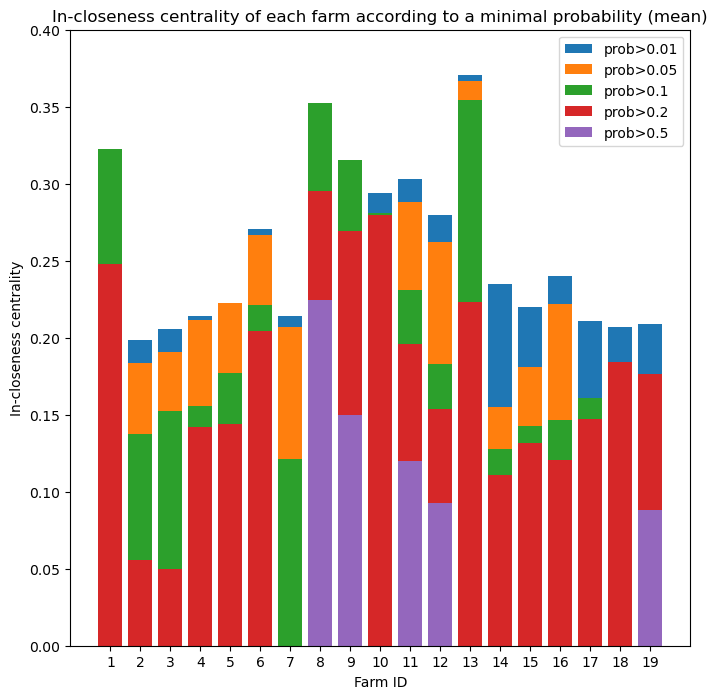

In [9]:
# in-closeness centrality
# measure of the degree of connections required for the whole network to reach a destination 
# = 1/(mean number of connections from all other nodes)

# year = 2017

# with open(f"Graph_{year}.json", "r") as f:
#     data = json.load(f)
# G = nx.node_link_graph(data)

H = G.copy()
for nd in list(H.nodes()):
    if (nd, nd) in list(H.edges()):       
        H.remove_edge(nd, nd)
for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = - math.log(G.edges[e[0], e[1]]['prob'])
    # the path is shorter when the probability is higher
    
closeness = nx.closeness_centrality(H, u=None, distance='weight', wf_improved=True)
closeness


fig, ax = plt.subplots(figsize=(8, 8))
list_prob = [0.01, 0.05, 0.1, 0.2, 0.5]
farms = np.arange(1, 20)

for prob in list_prob :
    for e in list(H.edges()):
        if H.edges[e[0], e[1]]['prob'] < prob :
            H.remove_edge(e[0], e[1])
    closeness = nx.closeness_centrality(H, u=None, distance='weight', wf_improved=True)
    values = []
    for ID in farms :
        values.append(closeness[ID])
    plt.xticks(farms, farms)
    plt.bar(farms, values, label = f'prob>{prob}')
    ax.set_ylim([0, 0.4])

ax.legend()
# ax.set_title(f'In-closeness centrality of each farm according to a minimal probability ({year})')
ax.set_title(f'In-closeness centrality of each farm according to a minimal probability (mean)')
ax.set_xlabel("Farm ID")
ax.set_ylabel("In-closeness centrality")
plt.show()
# fig.savefig(f'In_closeness_centrality_min_prob_{year}')
fig.savefig(f'In_closeness_centrality_min_prob_mean')

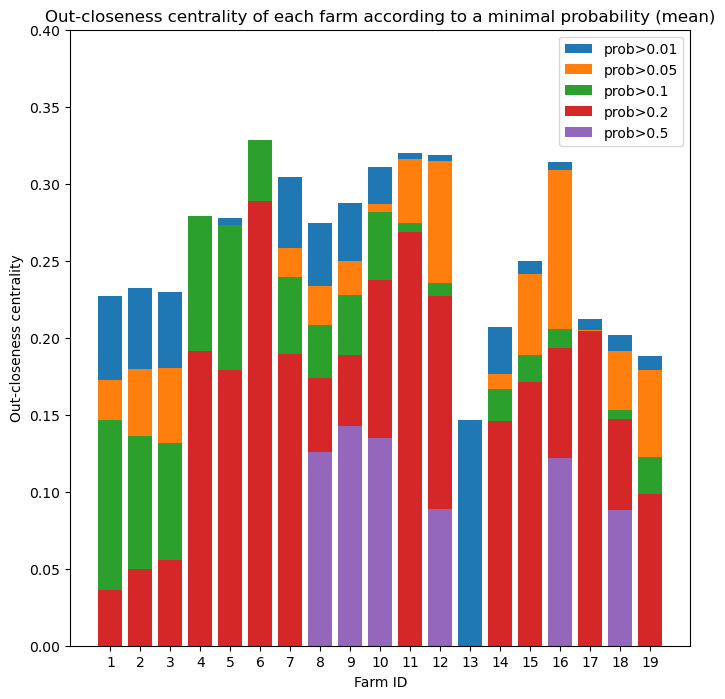

In [11]:
# out-closeness centrality
# measure of the degree of connections required for a source to reach the whole network  
# = 1/(mean number of connections to all other nodes)

# year = 2017
# with open(f"Graph_{year}.json", "r") as f:
#     data = json.load(f)
# G = nx.node_link_graph(data)

H = G.copy()
for nd in list(H.nodes()):
    if (nd, nd) in list(H.edges()):       
        H.remove_edge(nd, nd)
for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = - math.log(G.edges[e[0], e[1]]['prob'])
    # the path is shorter when the probability is higher
    
fig, ax = plt.subplots(figsize=(8, 8))
list_prob = [0.01, 0.05, 0.1, 0.2, 0.5]
farms = np.arange(1, 20)

for prob in list_prob :
    for e in list(H.edges()):
        if H.edges[e[0], e[1]]['prob'] < prob :
            H.remove_edge(e[0], e[1])
    closeness = nx.closeness_centrality(H.reverse(), u=None, distance='weight', wf_improved=True) # use H.reverse() to determine out-closeness centrality
    values = []
    for ID in farms :
        values.append(closeness[ID])
    plt.xticks(farms, farms)
    plt.bar(farms, values, label = f'prob>{prob}')
    ax.set_ylim([0, 0.4])

ax.legend()
# ax.set_title(f'Out-closeness centrality of each farm according to a minimal probability ({year})')
ax.set_title(f'Out-closeness centrality of each farm according to a minimal probability (mean)')
ax.set_xlabel("Farm ID")
ax.set_ylabel("Out-closeness centrality")
plt.show()
# fig.savefig(f'Out_closeness_centrality_min_prob_{year}')
fig.savefig(f'Out_closeness_centrality_min_prob_mean')

### Load centrality ###

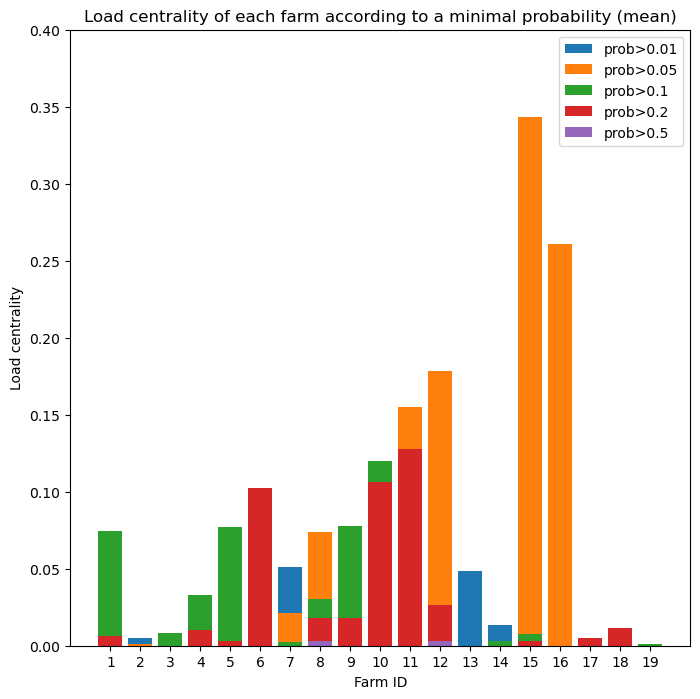

In [15]:
# load centrality
# the fraction of all shortest paths that pass through a node

# year = 2017
# with open(f"Graph_{year}.json", "r") as f:
#     data = json.load(f)
# G = nx.node_link_graph(data)

H = G.copy()
for nd in list(H.nodes()):
    if (nd, nd) in list(H.edges()):       
        H.remove_edge(nd, nd)
for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = - math.log(G.edges[e[0], e[1]]['prob'])
    # the path is shorter when the probability is higher
    
fig, ax = plt.subplots(figsize=(8, 8))
list_prob = [0.01, 0.05, 0.1, 0.2, 0.5]
farms = np.arange(1, 20)

for prob in list_prob :
    for e in list(H.edges()):
        if H.edges[e[0], e[1]]['prob'] < prob :
            H.remove_edge(e[0], e[1])
    load = nx.load_centrality(H, v=None, cutoff=None, normalized=True, weight='wheight')
    values = []
    for ID in farms :
        values.append(load[ID])
    plt.xticks(farms, farms)
    plt.bar(farms, values, label = f'prob>{prob}')
    ax.set_ylim([0, 0.4])

ax.legend()
# ax.set_title(f'Load centrality of each farm according to a minimal probability ({year})')
ax.set_title(f'Load centrality of each farm according to a minimal probability (mean)')
ax.set_xlabel("Farm ID")
ax.set_ylabel("Load centrality")
plt.show()
# fig.savefig(f'Load_centrality_min_prob_{year}')
fig.savefig(f'connectivity_metrics/Load_centrality_min_prob_mean')

In [3]:
# # in-degree (centrality)
# # sum of the number of inward connections made to a destination location as a percentage of the total nodes (n)
# # It doesn't use edge weights

# G1 = G.copy()
# for nd in list(G1.nodes()):
#     if (nd, nd) in list(G1.edges()):       
#         G1.remove_edge(nd, nd)

# in_degree = nx.in_degree_centrality(G1)
# print(in_degree)
# out_degree = nx.out_degree_centrality(G1)
# print(out_degree)

### Betweenness centrality ###

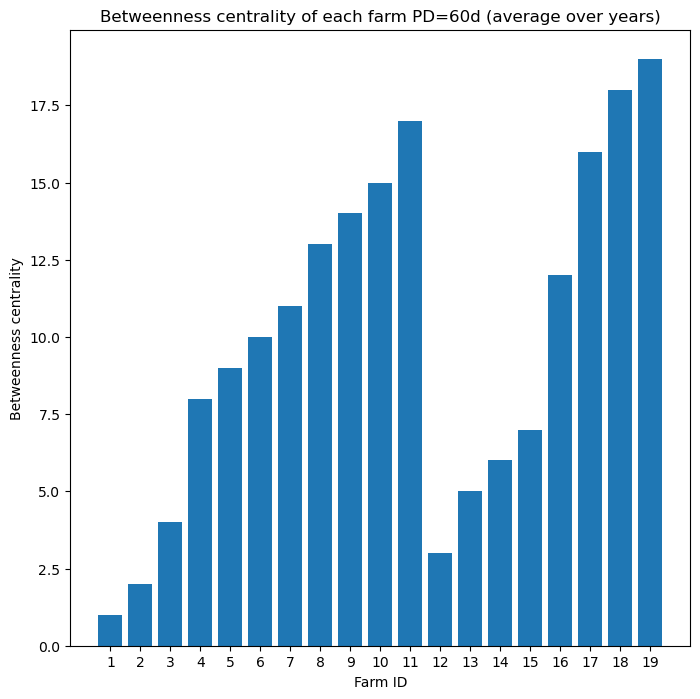

In [17]:
# betweenness centrality = similar to load centrality
# the total number of shortest paths between nodes (s and t) that pass through another node (u)

# year = 2012
# with open(f"Graph_{year}.json", "r") as f:
#     data = json.load(f)
# G = nx.node_link_graph(data)

with open(f"Graph_json/Graph_mean.json", "r") as f:
    data = json.load(f)
G = nx.node_link_graph(data)

H = G.copy()
for nd in list(H.nodes()):
    if (nd, nd) in list(H.edges()):       
        H.remove_edge(nd, nd) # removing connections from one node to itself
        
# H.remove_nodes_from([10, 19]) # testing if removing nodes impacts the results


for e in list(H.edges()):
    H.edges[e[0], e[1]]['weight'] = - math.log(G.edges[e[0], e[1]]['prob'])
    # the path is shorter when the probability is higher
    
fig, ax = plt.subplots(figsize=(8, 8))
farms = np.arange(1, 20)
# farms = [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18]

btw = nx.betweenness_centrality(H, k=None, normalized=True, weight='weight', endpoints=False, seed=None)
plt.xticks(farms, farms)
plt.bar(farms, btw)
# ax.set_ylim([0, 1])

ax.set_title(f'Betweenness centrality of each farm PD=60d (average over years)')
ax.set_xlabel("Farm ID")
ax.set_ylabel("Betweenness centrality")
plt.show()
fig.savefig(f'connectivity_metrics/Betweenness_centrality_min_prob_mean')
# fig.savefig(f'Test_betweeneess_centrality')